## Data Exploration - Armed Conflict Location & Event Data (ACLED)

[ACLED](https://acleddata.com/curated-data-files/) is a disaggregated data collection, analysis, and crisis mapping initiative. ACLED collects information on the dates, actors, locations, fatalities, and types of all reported political violence and protest events around the world. Data are updated weekly. This report is interested in the following dataframes provided by ACLED:

- **Disorder Involving Health Workers -** Political violence targeting health workers and demonstrations involving health workers.
- **Disorder Involving the Media -** Political violence and demonstrations involving journalists and media workers.
- **Disorfer Involving Peacekeepers -** Political violence and demonstration events involving actors directly affiliated with official peacekeeping missions.
- **Disorder Targeting Women & Demonstrations Featuring Women -** Violence targeting women, as well as demonstrations featuring women.

Before beginning analysis of the text data, review other features in the data.

In [14]:
# Load Packages
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numpy as np
import re
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns

import optuna
import optuna.visualization as vis
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor


In [2]:
# Load Data

df_gender = pd.read_csv('Data/gender_Apr25-1.csv')
df_health = pd.read_csv('Data/healthworkers_Apr18.csv')
df_journalists = pd.read_csv('Data/journalists_Apr18.csv')
df_peacekeeping = pd.read_excel('Data/peacekeeping_2025-05-02.xlsx').rename(columns=str.lower) # Standardize column names to lowercase, like other dataframes

# Add column indicating target group
df_gender['target_group'] = 'Women'
df_health['target_group'] = 'Health Worker'
df_journalists['target_group'] = 'Media'
df_peacekeeping['target_group'] = 'Peacekeeper'

# Combine dataframes
df_full = pd.concat(
    [df_gender, df_health, df_journalists, df_peacekeeping],
    ignore_index=True,
    sort=False
)

df_full.head()

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,target_group
0,ARG16601,2025-04-25,2025,1,Demonstrations,Protests,Peaceful protest,Protesters (Argentina),Women (Argentina),Protesters,...,-30.8568,-64.5258,1,El Diario de Carlos Paz,Subnational,"On 25 April 2025, in Capilla del Monte (Cordob...",0,crowd size=large,1745881584,Women
1,BRA96908,2025-04-25,2025,2,Political violence,Violence against civilians,Attack,CV: Red Command,NaN,Political militia,...,-12.9711,-38.5108,1,Alo Juca; Bnews (Brazil),Subnational-National,"Around 25 April 2025 (as reported), in Salvado...",1,women targeted: girls,1745881585,Women
2,ISR45719,2025-04-25,2025,1,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Shift 101; Women (Israel),Protesters,...,31.7690,35.2163,1,Haaretz,National,"On 25 April 2025, about 200 Israelis from the ...",0,crowd size=about 200,1745881590,Women
3,MEX103000,2025-04-25,2025,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Mexico),NaN,Political militia,...,21.1220,-101.6832,1,Zona Franca,Subnational,"On 25 April 2025, in Leon de los Aldama, Guana...",1,NaN,1745881592,Women
4,MEX103223,2025-04-25,2025,1,Political violence,Violence against civilians,Attack,Unidentified Gang (Mexico),NaN,Political militia,...,20.2216,-97.5349,1,Imagen del Golfo,Subnational,"On 25 April 2025, in Sabanas de Xalostoc, Vera...",2,women targeted: relatives of targeted groups o...,1745881593,Women


In [3]:
df_full.isnull().sum()

event_id_cnty              0
event_date                 0
year                       0
time_precision             0
disorder_type              0
event_type                 0
sub_event_type             0
actor1                     0
assoc_actor_1          34989
inter1                     0
actor2                103273
assoc_actor_2         111568
inter2                103273
interaction                0
civilian_targeting    118802
iso                        0
region                     0
country                    0
admin1                     0
admin2                  3180
admin3                 85415
location                   0
latitude                   0
longitude                  0
geo_precision              0
source                     0
source_scale               0
notes                      0
fatalities                 0
tags                   39276
timestamp                  0
target_group               0
dtype: int64

In [4]:
# Number of occurences by target group
print(df_full['target_group'].value_counts())

target_group
Women            84118
Health Worker    43909
Media            20542
Peacekeeper       3556
Name: count, dtype: int64


### Data Cleaning & PreProcessing

In [5]:
# Check for duplicate rows
df_full.duplicated().sum()

0

We joined four data sets together, targetting women, Peacekeepers, the media, and healthcare workers. Are these data frames mutually exclusive? Eg. An attack against a Peacecorps mission with female Peacecorps members isn't recorded as Peacekeeper target and Gender target

In [6]:
df_full.duplicated(subset=['event_id_cnty']).sum()

3928

Stnadardize inputs for 'actor1' and 'actor2' features.

In [7]:
# Remove location in parentheses from 'actor1' and 'actor2'
df_full['actor1'] = df_full['actor1'].str.replace(r'\s*\(.*?\)', '', regex=True)
df_full['actor2'] = df_full['actor2'].str.replace(r'\s*\(.*?\)', '', regex=True)


In [8]:
# Missing values and their percentage of total observations
missing_info = df_full.isnull().sum().to_frame(name='missing_count')
missing_info['missing_percent'] = (missing_info['missing_count'] / len(df_full)) * 100

# Sort by count or percent, as preferred
missing_info = missing_info.sort_values(by='missing_count', ascending=False)

# Display the result
print(missing_info)

                    missing_count  missing_percent
civilian_targeting         118802        78.094988
assoc_actor_2              111568        73.339688
inter2                     103273        67.886935
actor2                     103273        67.886935
admin3                      85415        56.147905
tags                        39276        25.818242
assoc_actor_1               34989        23.000164
admin2                       3180         2.090386
location                        0         0.000000
latitude                        0         0.000000
longitude                       0         0.000000
event_id_cnty                   0         0.000000
source                          0         0.000000
source_scale                    0         0.000000
notes                           0         0.000000
fatalities                      0         0.000000
timestamp                       0         0.000000
geo_precision                   0         0.000000
region                         

In [9]:
df_full['sub_event_type'].unique()

array(['Peaceful protest', 'Attack', 'Abduction/forced disappearance',
       'Protest with intervention', 'Sexual violence',
       'Violent demonstration', 'Mob violence', 'Arrests',
       'Remote explosive/landmine/IED', 'Air/drone strike',
       'Looting/property destruction', 'Other', 'Grenade',
       'Excessive force against protesters',
       'Shelling/artillery/missile attack', 'Disrupted weapons use',
       'Suicide bomb', 'Armed clash', 'Change to group/activity',
       'Non-violent transfer of territory', 'Chemical weapon',
       'Headquarters or base established', 'Agreement',
       'Government regains territory',
       'Non-state actor overtakes territory'], dtype=object)

**Subset the dataset with features of interest, removing features that are not predictive or wpild introduce too much noise.**

There are multiple features providing information on *Who*, *What*, *When*, and *Where* in the original data set. Some of these features however are duplicative , eg. `country` and `iso` (a three-digit numeric code assigned to each country or territory). Other features are not predictive of our target variable, eg. `source_scale` or `geo_precission`. 

There are also multiple features that are highly granular and would introduce considerable noise to our model without adding much predictive power, eg. `timestamps` as well as `admin1`, `admin2`, and `admin3`, each containing more precise location identifiers.

The data is subset initially based on features theorized to have the most predictive power while also considering data granularity, scarcity, and redundancy.

For the initial subset, the following features were selected:

- *When*
    - `year`
- *Where*
    - `iso`
    - `longitude` and `latitude`
- *What*
    - `event_type`
    - `sub_event_type`
- *Who*
    - `inter1` and `inter2`
    - `interaction`
- `fatalities` and `event_id_cnty` (unique identifier for each event) are also included.


In [31]:
# Subset the dataframe to include only selected features
selected_features = [
    'year', 'iso', 'longitude', 'latitude',
    'event_type', 'sub_event_type',
    'inter1', 'inter2', 'interaction',
    'fatalities', 'target_group'
]

df_subset = df_full[selected_features].copy()
df_subset.head()

,year,iso,longitude,latitude,event_type,sub_event_type,inter1,inter2,interaction,fatalities,target_group
0,2025,32,-64.5258,-30.8568,Protests,Peaceful protest,Protesters,NaN,Protesters only,0,Women
1,2025,76,-38.5108,-12.9711,Violence against civilians,Attack,Political militia,Civilians,Political militia-Civilians,1,Women
2,2025,376,35.2163,31.7690,Protests,Peaceful protest,Protesters,NaN,Protesters only,0,Women
3,2025,484,-101.6832,21.1220,Violence against civilians,Attack,Political militia,Civilians,Political militia-Civilians,1,Women
4,2025,484,-97.5349,20.2216,Violence against civilians,Attack,Political militia,Civilians,Political militia-Civilians,2,Women


Handle remaining missing values. `inter2` records the designation of a second main actor in an event should one be present. It is co-equal with `inter1`, and is only populated when there is a second main actor, so there are instances when it is missing.

There is a significant degree of missingness in `inter2`, but this feature and its relationship with `inter1` - captures in `interaction` - could be predictive of our target variable. For instance, while only one main actor `inter1` is indicative of something like a protest, the presence of a second main actor `inter2` opens up additional possibilities that there was some clash or standoff between the two main actors. For instance, protesters `inter1` classing with police forces `inter2`. 

In [32]:
df_subset.isnull().sum()

year                   0
iso                    0
longitude              0
latitude               0
event_type             0
sub_event_type         0
inter1                 0
inter2            103273
interaction            0
fatalities             0
target_group           0
dtype: int64

In [34]:
df_subset['inter2'] = df_subset['inter2'].fillna('None')
df_subset.isnull().sum()

year              0
iso               0
longitude         0
latitude          0
event_type        0
sub_event_type    0
inter1            0
inter2            0
interaction       0
fatalities        0
target_group      0
dtype: int64

**Test, Train, Validation Split**

In [35]:
label_encoder = LabelEncoder()

X = df_subset.drop('target_group', axis=1)
y = label_encoder.fit_transform(df_subset['target_group'])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

**Encode Categorical Variables**

Experiment with treating `year` as categorical and numerical.

Latitude and Longitude not linear features. Shouldn't StandardScaler them. Include them in a tree based model and run them independent in a clustering model?

In [37]:
categorical_features = ['event_type', 'sub_event_type','inter1', 'inter2', 'interaction', 'iso']
numerical_features = ['year', 'fatalities']

# Preprocessors for numerical and categorical data
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output= False), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

#Use the preprocessor to transform the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Random Forest

In [38]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

#Predicting the test set results and calculating the accuracy
print("Random Forest Classifier")
print("Test Set Accuracy: ", accuracy_score(y_test, rf_pred))

Random Forest Classifier
Test Set Accuracy:  0.6858833196384552


In [40]:
print(confusion_matrix(y_test, rf_pred))

[[ 4018   563    14  4240]
 [  689  2148    15  1187]
 [    8     9   694    20]
 [ 1996   790    26 14008]]


**Optuna**

*Should take around 12 minutes*

In [45]:
#Define objective function for Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300, step=100)
    max_depth = trial.suggest_categorical('max_depth', [None, 10, 20, 30])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score

# Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # 30 trials or 5 minutes (timeout=300) removed

# Best hyperparameters
print("Best parameters:", study.best_params)
print("Best cross-validated accuracy:", study.best_value)

# Train final model with best parameters
rf_optuna = RandomForestClassifier(**study.best_params, random_state=42)
rf_optuna.fit(X_train, y_train)
rf_pred = rf_optuna.predict(X_test)

# Evaluate on test set
print("Best Random Forest Classifier")
print("Test Set Accuracy: ", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))

[I 2025-05-17 20:54:37,464] A new study created in memory with name: no-name-9d809136-ec7e-4b9d-a663-d83e8bcd5395
[I 2025-05-17 20:56:17,762] Trial 0 finished with value: 0.6789153656532456 and parameters: {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 9}. Best is trial 0 with value: 0.6789153656532456.
[I 2025-05-17 20:58:42,469] Trial 1 finished with value: 0.6246179129005751 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 9}. Best is trial 0 with value: 0.6789153656532456.
[I 2025-05-17 21:02:39,989] Trial 2 finished with value: 0.6613640098603122 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 5}. Best is trial 0 with value: 0.6789153656532456.
[I 2025-05-17 21:03:59,474] Trial 3 finished with value: 0.661618734593262 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 4}. Best is trial 0 with value: 0.6789153656532456.
[I 2025-05-17 21:06:32,318] Trial 4 finished with value: 0.678619556285

Best parameters: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 10}
Best cross-validated accuracy: 0.6914133114215284
Best Random Forest Classifier
Test Set Accuracy:  0.690024650780608
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.45      0.52      8835
           1       0.62      0.53      0.58      4039
           2       0.95      0.94      0.95       731
           3       0.72      0.84      0.78     16820

    accuracy                           0.69     30425
   macro avg       0.73      0.69      0.70     30425
weighted avg       0.68      0.69      0.68     30425



In [43]:
# Visualize optimization history (score per trial)
vis.plot_optimization_history(study).show()

# Visualize hyperparameter importance
vis.plot_param_importances(study).show()

# Visualize parallel coordinate plot (hyperparameters vs. score)
vis.plot_parallel_coordinate(study).show()

ValueError: Cannot evaluate parameter importances with only a single trial.

**Feature Importance**

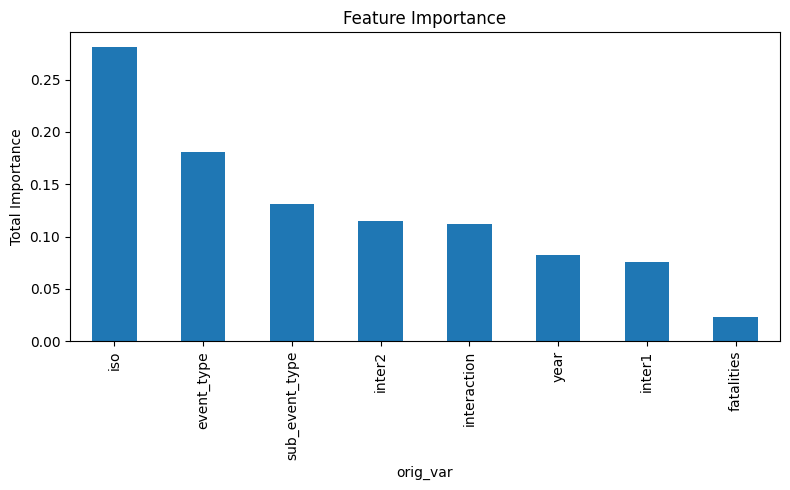

In [26]:
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
num_features = numerical_features
feature_names = np.concatenate([cat_features, num_features])

importances = rf_optuna.feature_importances_

# Map each feature to its original variable
def get_original_var(name):
    for var in categorical_features:
        if name.startswith(var + '_'):
            return var
    if name in numerical_features:
        return name
    return 'other'

orig_vars = [get_original_var(f) for f in feature_names]

# Aggregate importances by original variable
df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances, 'orig_var': orig_vars})
agg_imp = df_imp.groupby('orig_var')['importance'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
agg_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()

## Exploration of `df_full`

### Map Locations of Occurences

In [21]:
# Drop rows with missing coordinates
df_map = df_full.dropna(subset=['latitude', 'longitude'])

# Create geometry points
geometry = [Point(xy) for xy in zip(df_map['longitude'], df_map['latitude'])]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(df_map, geometry=geometry, crs='EPSG:4326')


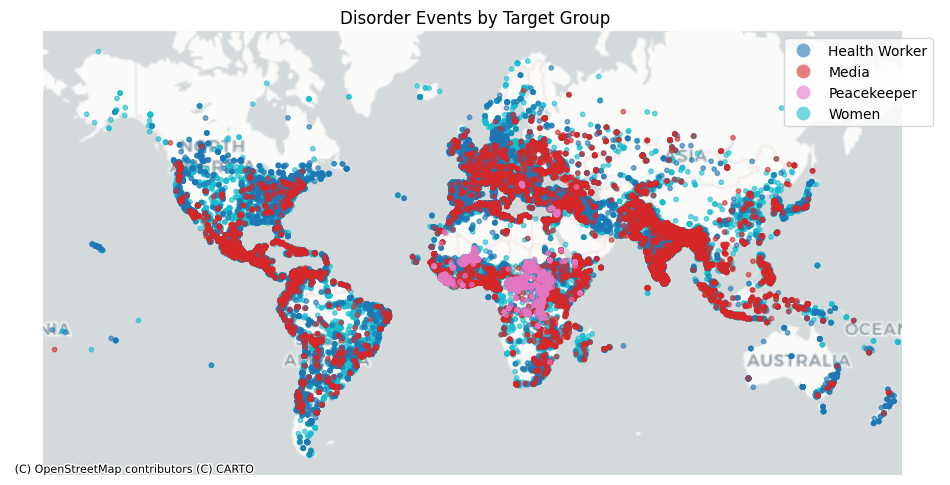

In [22]:
# Project to Web Mercator (required for basemaps)
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_web.plot(ax=ax, column='target_group', legend=True, markersize=10, alpha=0.6)

# Use a reliable basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.title("Disorder Events by Target Group")
plt.axis('off')
plt.show()

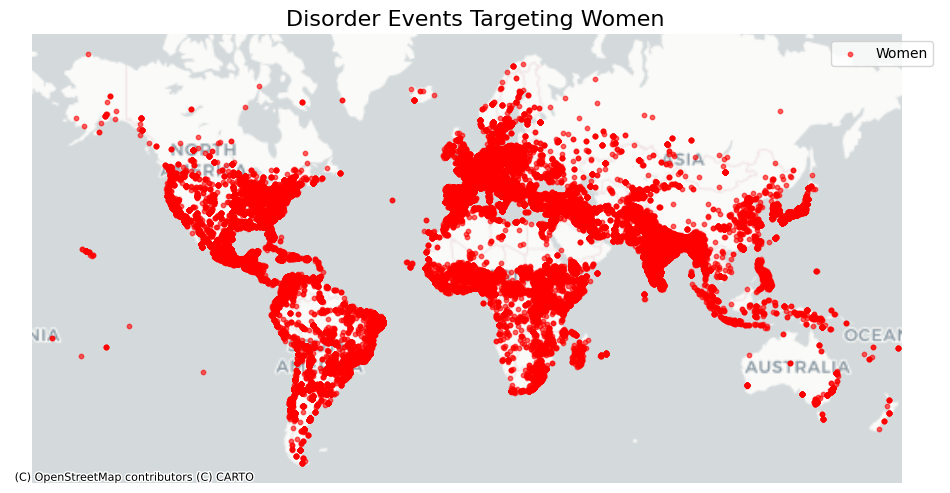

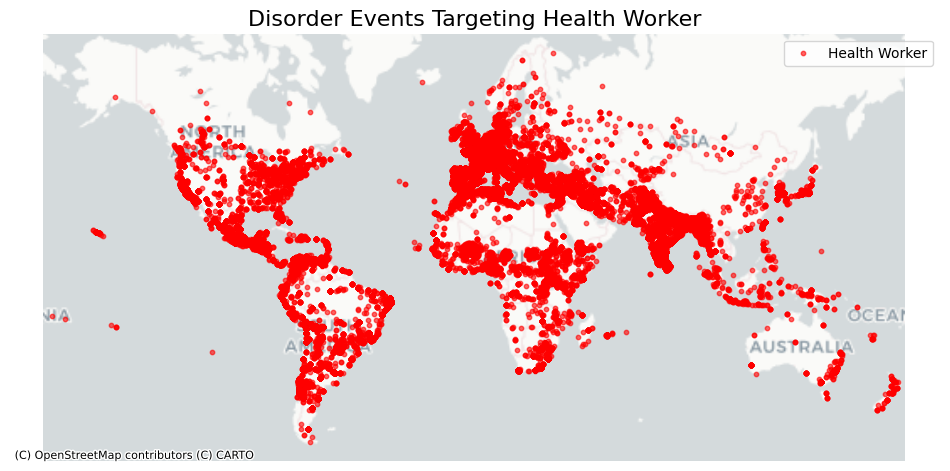

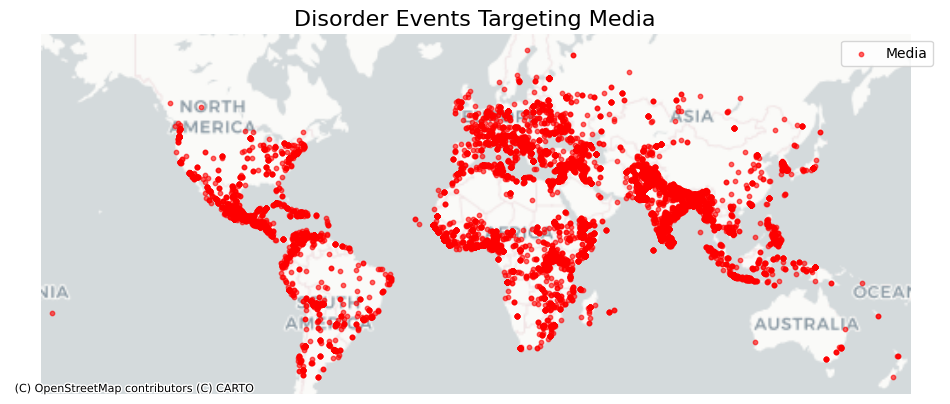

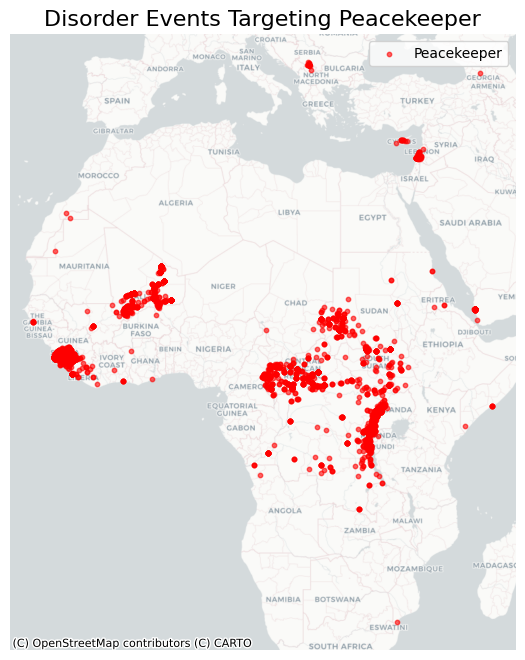

In [23]:
# Get unique groups
groups = gdf_web['target_group'].dropna().unique()

# Loop over each group and plot
for group in groups:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    subset = gdf_web[gdf_web['target_group'] == group]
    subset.plot(ax=ax, markersize=10, alpha=0.6, color='red', label=group)
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    ax.set_title(f"Disorder Events Targeting {group}", fontsize=16)
    ax.set_axis_off()
    plt.legend()
    plt.show()

### Plots with number of attacks by target_group per region

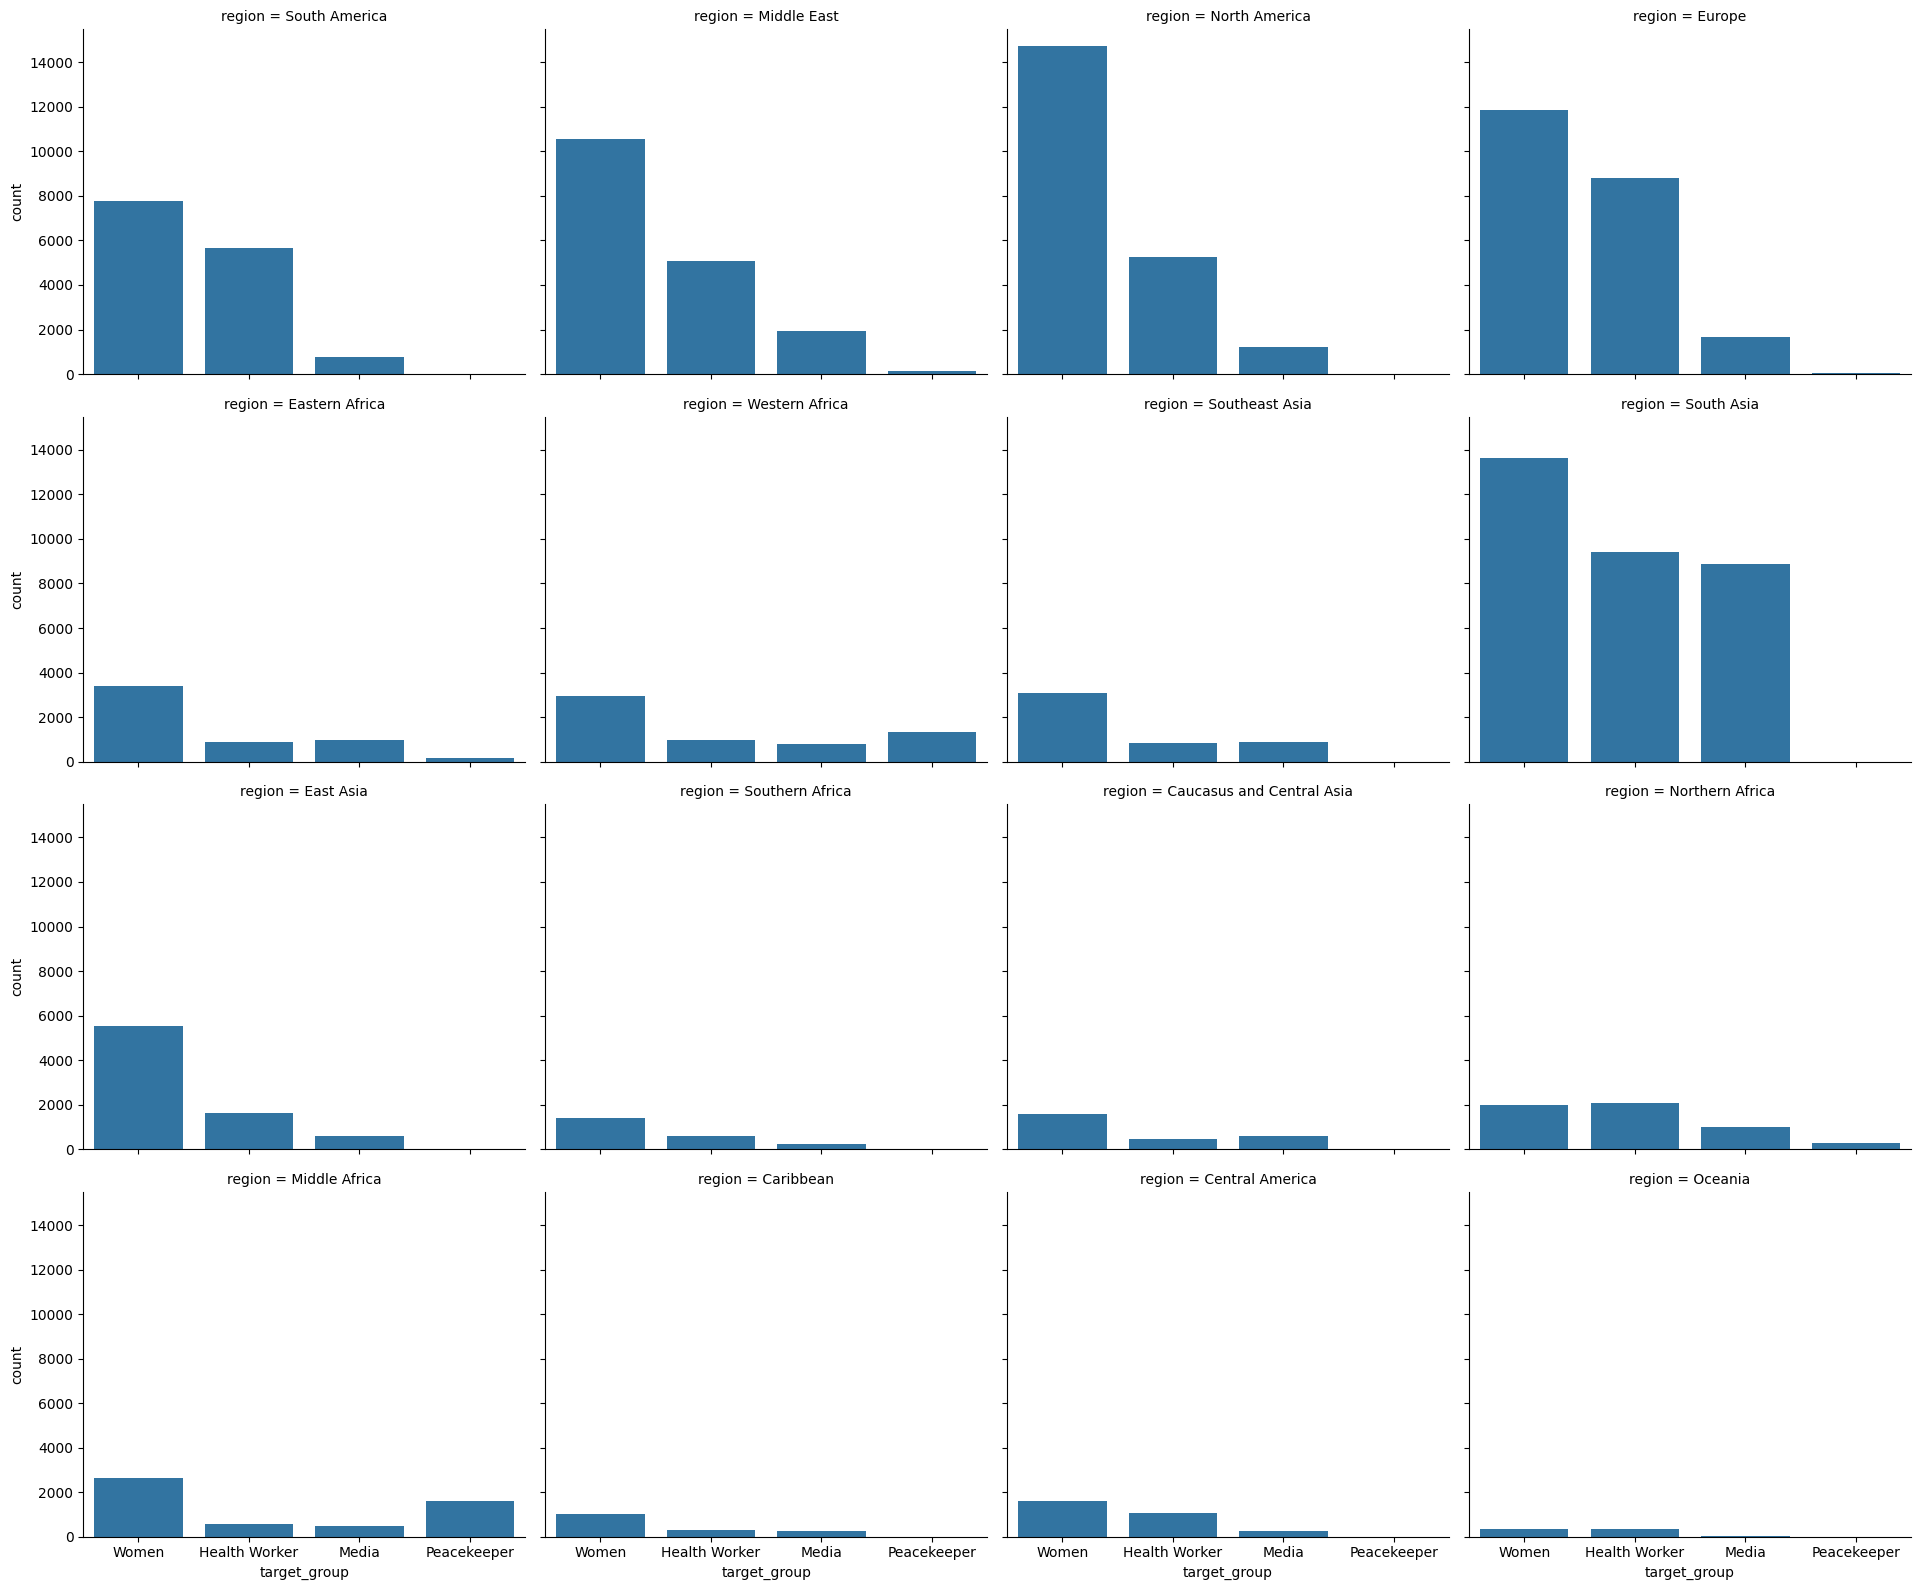

In [24]:
import seaborn as sns

# Count attacks by target in each region
sns.catplot(data=df_full, 
            kind="count", 
            x="target_group", 
            col="region", 
            col_wrap=4,     # number of plots per row
            height=4, 
            aspect=1.2)

plt.tight_layout()
plt.show()